In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [4]:
#Loading data
df = pd.read_csv(r"C:\Users\Velimir\iCloudDrive\Documents\Python for AI\Project\Large set\ufc_processed.csv")

In [5]:
#Adding features and scaler
feature_names = joblib.load(r"C:\Users\Velimir\iCloudDrive\Documents\Python for AI\ufc_features.pkl")
scaler=joblib.load(r"C:\Users\Velimir\iCloudDrive\Documents\Python for AI\ufc_scaler.pkl")

print("Feature names loaded.")
print("Scaler loaded.")
print("Number of features:", len(feature_names))

Feature names loaded.
Scaler loaded.
Number of features: 45


In [6]:
X = df.drop(columns=["winner"])
y = df["winner"]
#making sure x has the same order as the pkl file
X = X[feature_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data ready.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)



X_train: (5951, 45)
X_test: (1488, 45)
y_train: (5951,)
y_test: (1488,)
Scaled data ready.
X_train_scaled: (5951, 45)
X_test_scaled: (1488, 45)


In [7]:
#Sequential NN model creation
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(1, activation="sigmoid"))

c:\Users\Velimir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#Compiling model

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
#Adding Callbacks

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_ufc_nn_model.keras",
    monitor="val_loss",
    save_best_only=True
)

total_rows = len(df)

test_rows = len(X_test)
train_val_rows = len(X_train)

nn_train_rows = int(train_val_rows * 0.8)   # because validation_split=0.2
nn_val_rows = train_val_rows - nn_train_rows

print("Neural Network Data Split")
print(f"Full dataset size: {total_rows}")

print(f"Final test set: {test_rows} rows")
print(f"Training + validation set: {train_val_rows} rows")

print(f"Neural Network actual training data: {nn_train_rows} rows")
print(f"Neural Network validation data: {nn_val_rows} rows")

print("\nPercentages of full dataset:")
print(f"NN training data: {(nn_train_rows / total_rows) * 100:.2f}%")
print(f"NN validation data: {(nn_val_rows / total_rows) * 100:.2f}%")
print(f"Final test set: {(test_rows / total_rows) * 100:.2f}%")


=== Neural Network Data Split ===
Full dataset size: 7439
Final test set: 1488 rows
Training + validation set: 5951 rows
Neural Network actual training data: 4760 rows
Neural Network validation data: 1191 rows

Percentages of full dataset:
NN training data: 63.99%
NN validation data: 16.01%
Final test set: 20.00%


In [ ]:
#Training the NN model


history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)


Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6626 - loss: 0.2265 - val_accuracy: 0.7053 - val_loss: 0.1846
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7095 - loss: 0.1910 - val_accuracy: 0.7187 - val_loss: 0.1792
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7168 - loss: 0.1835 - val_accuracy: 0.7355 - val_loss: 0.1751
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7282 - loss: 0.1827 - val_accuracy: 0.7305 - val_loss: 0.1735
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7271 - loss: 0.1771 - val_accuracy: 0.7355 - val_loss: 0.1718
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7353 - loss: 0.1737 - val_accuracy: 0.7338 - val_loss: 0.1703
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7384 - loss: 0.1714 - val_accuracy: 0.7305 - val_loss: 0.1673
Epoch 8/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7519 - loss: 0.1675 - val_accu

In [19]:
#Predictions
y_probability_nn = model.predict(X_test_scaled)

y_pred_nn = np.round(y_probability_nn)
y_pred_nn = y_pred_nn.flatten().astype(int)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [20]:
#Checking accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("Neural Network Accuracy:", accuracy_nn)
print("Neural Network F1-score:", f1_nn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))



Neural Network Accuracy: 0.75
Neural Network F1-score: 0.8126888217522659

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       513
           1       0.80      0.83      0.81       975

    accuracy                           0.75      1488
   macro avg       0.72      0.72      0.72      1488
weighted avg       0.75      0.75      0.75      1488



Neural Network Accuracy: 0.75
Neural Network F1-score: 0.8126888217522659

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       513
           1       0.80      0.83      0.81       975

    accuracy                           0.75      1488
   macro avg       0.72      0.72      0.72      1488
weighted avg       0.75      0.75      0.75      1488



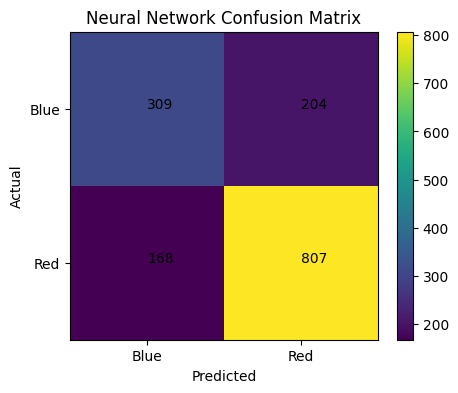

In [21]:
# 11. EVALUATE

accuracy_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("Neural Network Accuracy:", accuracy_nn)
print("Neural Network F1-score:", f1_nn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


# %%
# 12. CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Neural Network Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Blue", "Red"])
plt.yticks([0, 1], ["Blue", "Red"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j])

plt.show()


In [22]:
model.save("ufc_v1_neural_network.keras")

print("Neural Network model saved as ufc_final_neural_network.keras")

Neural Network model saved as ufc_final_neural_network.keras
